# Chapter 3. 비지도 학습과 데이터 전처리

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy as sp
import IPython
import sklearn
import mglearn

print('Python 버전:', sys.version)
print('numpy 버전:', np.__version__)
print('pandas 버전:', pd.__version__)
print('matplotlib 버전:', matplotlib.__version__)

print('SciFy 버전:', sp.__version__)
print('IPython 버전:', IPython.__version__)
print('scikit-learn 버전:', sklearn.__version__)

from sklearn.model_selection import train_test_split
#plt.rc('font', family="Apple SD Gothic Neo")

Python 버전: 3.11.4 (main, Jul  5 2023, 14:15:25) [GCC 11.2.0]
numpy 버전: 1.24.3
pandas 버전: 1.5.3
matplotlib 버전: 3.7.1
SciFy 버전: 1.10.1
IPython 버전: 8.12.0
scikit-learn 버전: 1.2.2


## 3.1 비지도 학습의 종류
- **비지도 변환(Unsupervised transformation)**
> - **데이터를 새롭게 표현**하여 사람이나 다른 머신러닝 알고리즘이 원래 데이터보다 쉽게 해석할 수 있도록 만드는 알고리즘
> - **특성이 많은 고차원 데이터를 특성의 수를 줄이면서 꼭 필요한 특징을 포함한 데이터로 표현하는 방법인 차원 축소**
> - 차원 축소의 대표적인 예는 시각화를 위해 데이터셋을 2차원으로 변경하는 경우
- **군집 알고리즘(Clustering)** : 군집은 데이터를 비슷한 것끼리 그룹으로 묶는 것

## 3.2 비지도 학습의 도전 과제
- 비지도 학습은 보통 레이블이 없는 데이터에 적용하기에 **알고리즘이 유용한 것을 학습했는지 혹은 올바른 출력인지 평가 하는 것이 어려움**
- **지도 학습의 전처리 단계에서도 사용**
> - 비지도 학습 알고리즘은 데이터 과학자가 데이터를 더 잘 이해하고 싶을 때 탐색적 분석 단계에서 많이 사용
> - **비지도 학습 결과로 새롭게 표현된 데이터를 사용해 학습하면 지도 학습의 정확도가 좋아지기도 하며, 메모리와 시간 절약 가능**
> - 지도 학습 알고리즘에서 전처리와 스케일 조정을 자주 사용하지만, **스케일 조정 메서드는 지도 정보(supervised information)을 사용하지 않으므로 비지도 방식으로 볼 수 있음**

## 3.3 데이터 전처리와 스케일 조정
- 신경망과 SVM과 같은 알고리즘은 데이터의 스케일에 매우 민감 -> 알고리즘에 맞게 데이터의 특성 값을 조정
- **보통 특성마다 스케일을 조정해서 데이터를 변경함**

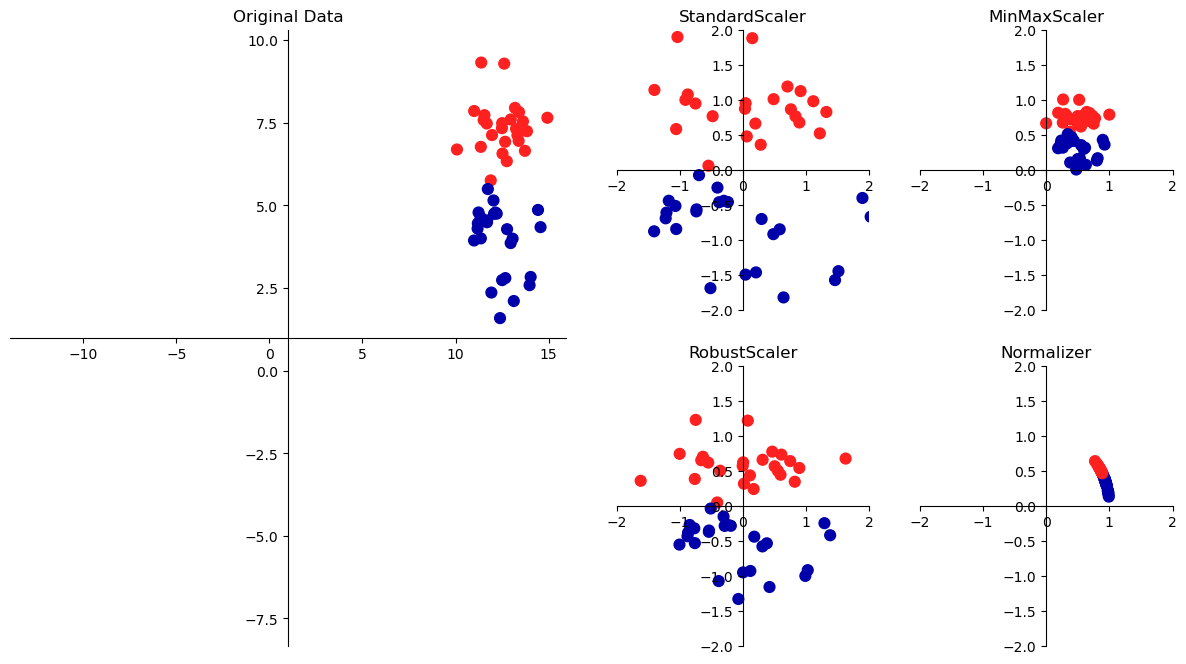

In [2]:
mglearn.plots.plot_scaling()

### 3.3.1 여러가지 전처리 방법
- 모든 추정기와 마찬가지로 **스케일링은 훈련 데이터로만 수행해야함**
    - 훈련 세트 이외에는 어떤 것에도 fit()이나 fit_transform() 메서드를 사용해서는 안됨
    - 훈련 세트 값은 항상 특정 범위로 스케일링 되지만 새로운 데이터에 이상치가 있다면 이 범위 밖으로 스케일링 될 것
    - 이를 원치 않는다면 **MinMaxScaler의 clip 매개변수를 True로 지정**

- **각 특성은 대칭 분포를 가지게 만드는 것이 좋음**
    - 특성 분포의 꼬리가 두꺼울 때(평균에서 멀리 떨어진 값이 지수적으로 줄어들지 않는 경우)
    - **min-max 스케일링과 표준화는 대부분의 값을 작은 범위로 압축**
    - 두꺼운 꼬리를 줄이고 대략적으로 대칭이 되도록 만드는 것을 추천함
    - 오른쪽 꼬리가 두꺼운 양수 특성인 경우 일반적으로 특성을 제곱근으로 변환
    - **멱법칙 분포처럼 특성 분포의 꼬리가 아주 길고 두껍다면 특성을 로그값으로 바꾸는 것이 도움이 됨**

- 타깃값도 필요시 전처리를 통한 변환이 필요함
    - 대부분의 사이킷런 변환기에는 역변환을 수행하는 **```inverse_transform()```** 메서드가 존재
    - or TransformedTargetRegressor 활용 

- **StandardScaler(표준화)**
> - **각 특성의 평균을 0, 분산을 1로 변경하여 모든 특성이 같은 크기를 가지게 함**
> - X - X(평균) / 표준편차, 해당 값을 표준 점수, 표준값 혹은 z-점수라고 함
> - 특성의 최솟값과 최댓값 크기를 제한하지 않음, 이상치에 덜 민감함
> - 희소 행렬을 밀집 행렬로 바꾸지 않고 스케일링 하려면 매개변수 **```with_mean=False```** 로 지정
> - 이 경우 데이터에서 평균을 빼지 않고 표준편차로 나누기만 수행하여 희소성이 깨지지 않음

- **RobustScaler**
> - 특성들이 같은 스케일을 갖게 된다는 통계적 측면에서는 StandardScaler와 유사
> - **평균과 분산 대신 중간값(median)과 사분위 값(quarile)을 사용 -> 전체 데이터와 아주 동떨어진 데이터 포인트(이상치)에 영향을 받지 않음**
> - 다른 스케일 조정 기법에서는 이상치가 문제가 될 수 있음
> - X - q2(중위) / (q3 - q1)

- Quantile Transformer
> - 기본적으로 1000개의 분위를 사용하여 데이터를 균등하게 분포
> - **RobustScaler와 비슷하게 이상치에 민감하지 않으며 전체 데이터를 0과 1사이로 압축함**
> - **분위 수는 *n_quantiles* 매개변수에서 설정, 기본값은 1000**
> - *output_distribution* 매개변수에서 normal로 지정하여 균등 분포가 아닌 정규분포로 출력 변환 가능

- **MinMaxScaler(정규화)**
> - **모든 특성이 정확하게 0과 1사이에 위치하도록 데이터를 변경**
> - X - X(min) / (X(max) - X(min)), 데이터에서 최솟값을 빼고 전체 범위로 나눔
> - **```feature_range```** 매개변수를 사용해 0~1이 아닌 다른 범위로 변경 가능

- **Normalizer**
> - 매우 다른 스케일 조정법
> - **특성 벡터의 유클리디안 길이가 1이 되도록 데이터 포인트를 조정 -> 지름이 1인 원(3차원일 땐 구)에 데이터 포인트를 투영**
> - 각 데이터 포인트가 다른 비율로(길이에 반비례하여) 스케일이 조정
> - norm 매개변수는 'l1', 'l2', 'max' 세 가지 옵션을 제공하며, **유클리디안 거리를 의미하는 'l2'가 기본값**
> - **StandardScaler, RobustScaler, MinMaxScaler는 각 열(특성)의 통계치를 이용하지만 Normalizer는 행(데이터포인트)마다 각기 정규화됨**

- Power Transformer
> - **데이터의 특성별로 정규분포 형태에 가깝도록 변환**
> - method 매개변수에 'yeo-johnson'(기본값)와 'box-cox' 알고리즘을 지정

### 3.3.2 데이터 변환 적용하기

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=1)

print(X_train.shape)
print(X_test.shape)

(426, 30)
(143, 30)


In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [5]:
scaler.fit(X_train)

MinMaxScaler()

> - **fit 메서드로 학습한 변환을 적용하려면, 즉 실제로 훈련 데이터의 스케일을 조정하려면 스케일 객체의 transform 메서드를 사용**
> - 단축 메서드
>> - **X_scaled = scaler.fit(X_train).transform(X_train) => X_scaled = scaler.fit_transform(X_train)**
>> - 테스트 세트에 fit_transform()을 적용하면 훈련세트에서 학습한 내용이 모두 지워짐 -> **테스트 세트에는 반드시 *transform()* 메서드를 사용**
> - scikit-learn의 transform은 새로운 데이터표현(representation)을 만들 때 사용하는 메서드임

In [6]:
# 데이터 변환
X_train_scaled = scaler.transform(X_train)
# 스케일이 조정된 후 데이터셋의 속성을 출력
print('변환된 후 크기:', X_train_scaled.shape)
print('스케일 조정전 특성별 최소값:\n', X_train.min(axis=0))
print('스케일 조정전 특성별 최대값:\n', X_train.max(axis=0))
print('스케일 조정후 특성별 최소값:\n', X_train_scaled.min(axis=0))
print('스케일 조정후 특성별 최대값:\n', X_train_scaled.max(axis=0))

변환된 후 크기: (426, 30)
스케일 조정전 특성별 최소값:
 [6.981e+00 9.710e+00 4.379e+01 1.435e+02 5.263e-02 1.938e-02 0.000e+00
 0.000e+00 1.060e-01 5.024e-02 1.153e-01 3.602e-01 7.570e-01 6.802e+00
 1.713e-03 2.252e-03 0.000e+00 0.000e+00 9.539e-03 8.948e-04 7.930e+00
 1.202e+01 5.041e+01 1.852e+02 7.117e-02 2.729e-02 0.000e+00 0.000e+00
 1.566e-01 5.521e-02]
스케일 조정전 특성별 최대값:
 [2.811e+01 3.928e+01 1.885e+02 2.501e+03 1.634e-01 2.867e-01 4.268e-01
 2.012e-01 3.040e-01 9.575e-02 2.873e+00 4.885e+00 2.198e+01 5.422e+02
 3.113e-02 1.354e-01 3.960e-01 5.279e-02 6.146e-02 2.984e-02 3.604e+01
 4.954e+01 2.512e+02 4.254e+03 2.226e-01 9.379e-01 1.170e+00 2.910e-01
 5.774e-01 1.486e-01]
스케일 조정후 특성별 최소값:
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
스케일 조정후 특성별 최대값:
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


In [7]:
# 테스트 데이터 변환
X_test_scaled = scaler.transform(X_test)
# 스케일이 조정된 후 데이터셋의 속성을 출력
print('스케일 조정후 특성별 최소값:\n', X_test_scaled.min(axis=0))
print('스케일 조정후 특성별 최대값:\n', X_test_scaled.max(axis=0))

스케일 조정후 특성별 최소값:
 [ 0.0336031   0.0226581   0.03144219  0.01141039  0.14128374  0.04406704
  0.          0.          0.1540404  -0.00615249 -0.00137796  0.00594501
  0.00430665  0.00079567  0.03919502  0.0112206   0.          0.
 -0.03191387  0.00664013  0.02660975  0.05810235  0.02031974  0.00943767
  0.1094235   0.02637792  0.          0.         -0.00023764 -0.00182032]
스케일 조정후 특성별 최대값:
 [0.9578778  0.81501522 0.95577362 0.89353128 0.81132075 1.21958701
 0.87956888 0.9333996  0.93232323 1.0371347  0.42669616 0.49765736
 0.44117231 0.28371044 0.48703131 0.73863671 0.76717172 0.62928585
 1.33685792 0.39057253 0.89612238 0.79317697 0.84859804 0.74488793
 0.9154725  1.13188961 1.07008547 0.92371134 1.20532319 1.63068851]


- 일부 특성은 0~1 범위를 벗어남 : 훈련세트의 통계값을 사용했기 때문
- **스케일 모델은 항상 훈련 세트와 테스트 세트에 같은 변환을 적용해야 함**

### 3.3.3 Quantile Trasnformer와 Power Transformer


#### <U>*Quantile Transformer*</U>
> - 기본적으로 1000개의 분위를 사용하여 데이터를 균등하게 분포
> - **RobustScaler와 비슷하게 이상치에 민감하지 않으며 전체 데이터를 0과 1사이로 압축함**
> - **분위 수는 *n_quantiles* 매개변수에서 설정, 기본값은 1000**
> - *output_distribution* 매개변수에서 normal로 지정하여 균등 분포가 아닌 정규분포로 출력 변환 가능
> - 최초 그림 예제와 동일한 데이터에 적용

In [8]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import QuantileTransformer, StandardScaler, PowerTransformer

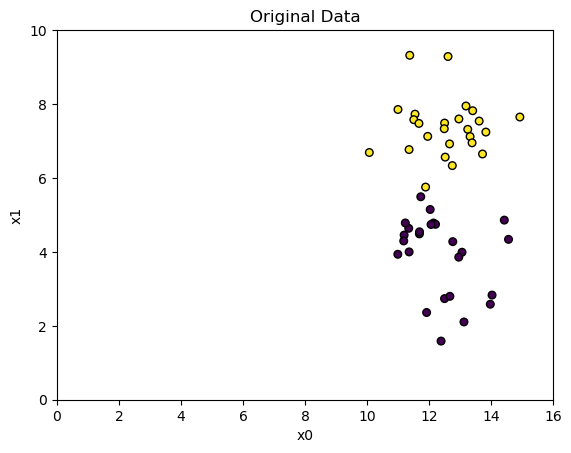

In [9]:
X, y = make_blobs(n_samples=50, centers=2, random_state=4, cluster_std=1)
X += 3

plt.scatter(X[:,0], X[:,1], c=y, s=30, edgecolors='black')
plt.xlim(0,16)
plt.xlabel('x0')
plt.ylim(0,10)
plt.ylabel('x1')
plt.title('Original Data')
plt.show()

In [10]:
df = pd.DataFrame(X)
df['y'] = y
df.head()

,0,1,y
0,12.143852,4.781174,0
1,11.888812,5.753391,1
2,11.344688,4.638243,0
3,11.922295,2.360068,0
4,10.993136,3.935285,0


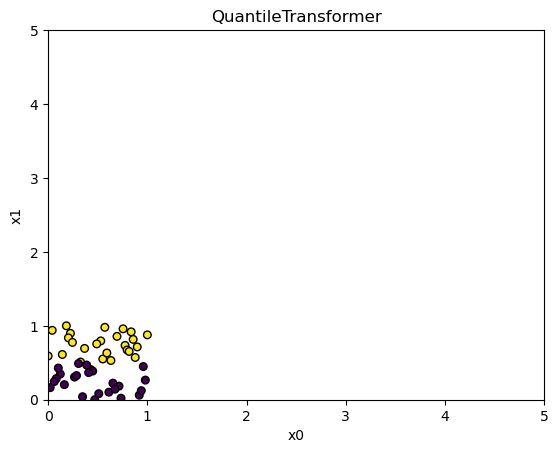

In [11]:
scaler = QuantileTransformer(n_quantiles=50)
X_trans = scaler.fit_transform(X)

plt.scatter(X_trans[:,0], X_trans[:,1], c=y, s=30, edgecolors='black')
plt.xlim(0,5)
plt.xlabel('x0')
plt.ylim(0,5)
plt.ylabel('x1')
plt.title(type(scaler).__name__)
plt.show()

> - 변환된 데이터의 히스토그램을 그려보면 균등분포를 쉽게 확인 가능

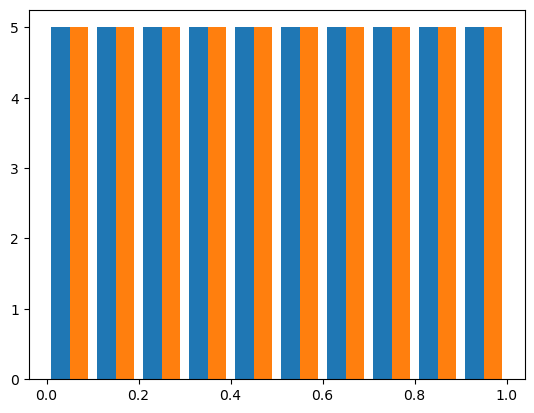

In [12]:
plt.hist(X_trans)
plt.show()

> - **Scaler 객체의 quantiles_ 속성에는 특성별로 계산된 분위 값**이 들어 있으므로 이 속성의 크기는 (n_quantiles, n_features)임

In [13]:
print(scaler.quantiles_.shape)
pd.DataFrame(scaler.quantiles_).head()

(50, 2)


,0,1
0,10.073912,1.586571
1,10.993136,2.103769
2,10.998153,2.360068
3,11.183781,2.583679
4,11.196798,2.735697


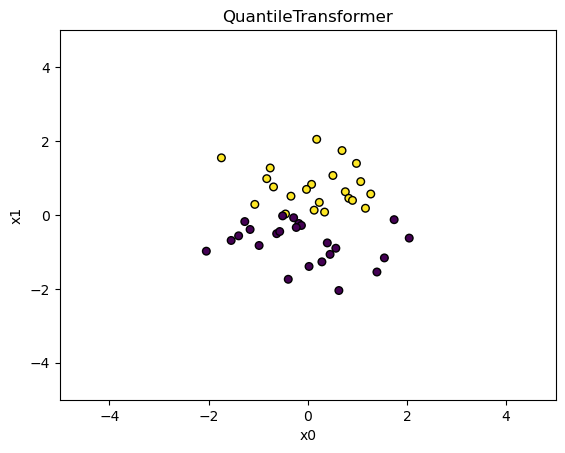

In [14]:
# 균등분포가 아닌 정규분포로 변환
scaler = QuantileTransformer(output_distribution='normal', n_quantiles=50)
X_trans = scaler.fit_transform(X)

plt.scatter(X_trans[:,0], X_trans[:,1], c=y, s=30, edgecolors='black')
plt.xlim(-5,5)
plt.xlabel('x0')
plt.ylim(-5,5)
plt.ylabel('x1')
plt.title(type(scaler).__name__)
plt.show()

#### <U>*Power Transformer*</U>
> - **데이터의 특성별로 정규분포 형태에 가깝도록 변환**
> - method 매개변수에 'yeo-johnson'(기본값)와 'box-cox' 알고리즘을 지정

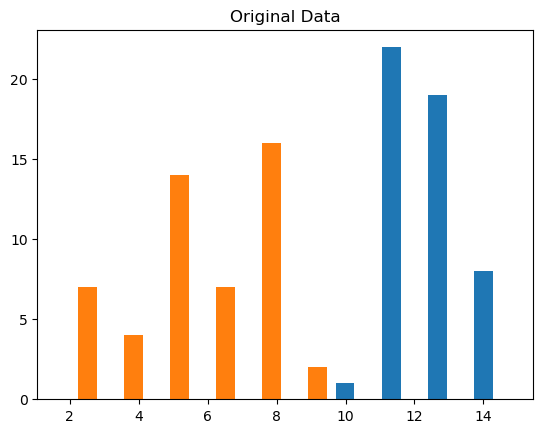

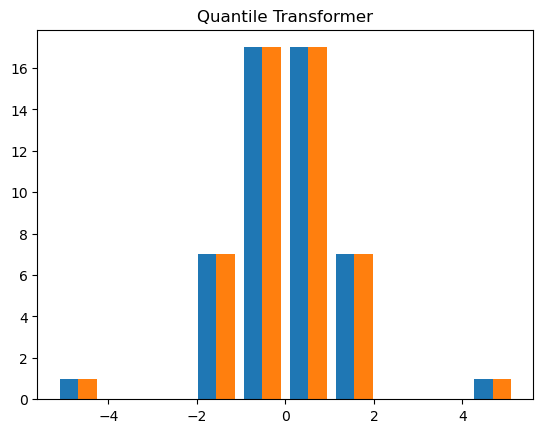

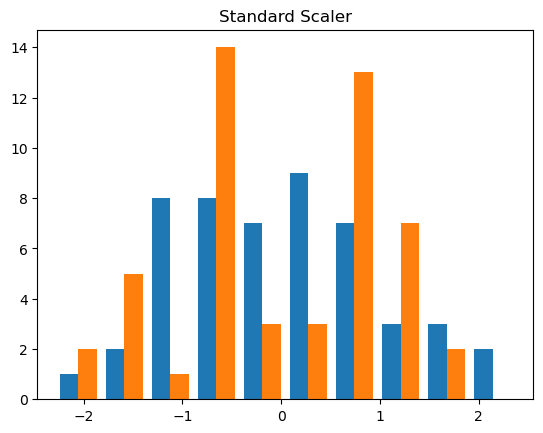

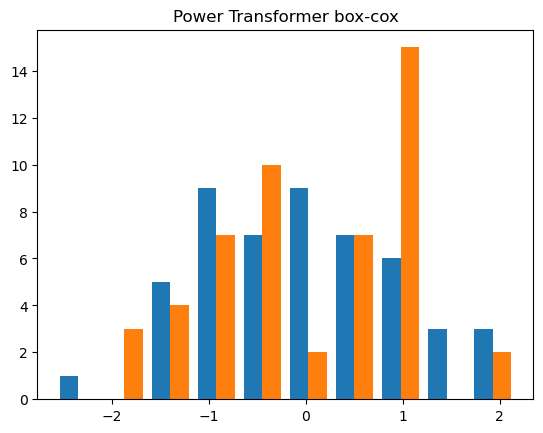

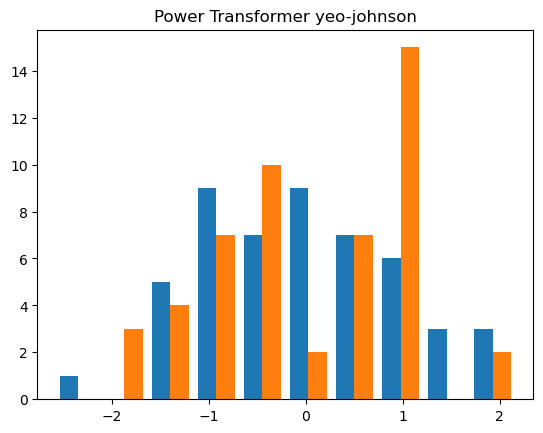

In [15]:
# QuantileTransformer와 StandardScaler, PowerTransformer의 알고리즘 비교
# Original Data
plt.hist(X)
plt.title('Original Data')
plt.show()

# Quantile Transformer
X_trans = QuantileTransformer(output_distribution='normal', n_quantiles=50).fit_transform(X)
plt.hist(X_trans)
plt.title('Quantile Transformer')
plt.show()

# Standard Scaler
X_trans = StandardScaler().fit_transform(X)
plt.hist(X_trans)
plt.title('Standard Scaler')
plt.show()

# Power Transformer
X_trans = PowerTransformer(method='box-cox').fit_transform(X)
plt.hist(X_trans)
plt.title('Power Transformer box-cox')
plt.show()

X_trans = PowerTransformer(method='yeo-johnson').fit_transform(X)
plt.hist(X_trans)
plt.title('Power Transformer yeo-johnson')
plt.show()

### 3.3.5 지도 학습에서 데이터 전처리 효과

In [16]:
from sklearn.svm import SVC

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)
svm = SVC(gamma='auto')
svm.fit(X_train, y_train)
print('테스트 세트 정확도:{:.2f}'.format(svm.score(X_test, y_test)))

테스트 세트 정확도:0.63


In [17]:
# MinMaxScaler로 전처리
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)
svm = SVC(gamma='auto')

# 0-1사이로 스케일 조정
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm.fit(X_train_scaled, y_train)
print('테스트 세트 정확도:{:.2f}'.format(svm.score(X_test_scaled, y_test)))

테스트 세트 정확도:0.95


In [18]:
# Standard Scaler로 전처리
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)
svm = SVC(gamma='auto')

# 평균 0, 분산 1을 갖도록 스케일 조정
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm.fit(X_train_scaled, y_train)
print('테스트 세트 정확도:{:.2f}'.format(svm.score(X_test_scaled, y_test)))

테스트 세트 정확도:0.97
